# Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

# Standard library
from pathlib import Path
import pprint

# Third-party libraries
import duckdb
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Custom osbad library for anomaly detection
import osbad.config as bconf
import osbad.hyperparam as hp
import osbad.modval as modval
import osbad.stats as bstats
import osbad.viz as bviz
from osbad.database import BenchDB
from osbad.scaler import CycleScaling
from osbad.model import ModelRunner

# Import dataset

## Define filepath

In [2]:
# Define a global variable to save fig output
# The definition of PIPELINE_OUTPUT_DIR can be
# found in config.py
PIPELINE_OUTPUT_DIR = bconf.PIPELINE_OUTPUT_DIR

In [3]:
# Load only the training dataset
db_filepath = str(
    Path.cwd()
    .parent
    .joinpath("database","train_dataset_severson.db"))

## Get the cell inventory of the training dataset

In [4]:
# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all training dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_train_dataset_sv").fetchdf()

# Get the cell index of training dataset
unique_cell_index_train = df_duckdb["cell_index"].unique()
print(f"Unique cell index: {unique_cell_index_train}")

Unique cell index: ['2017-05-12_5_4C-50per_3C_CH13' '2017-05-12_5_4C-50per_3C_CH14'
 '2017-05-12_5_4C-60per_3C_CH15' '2017-05-12_5_4C-60per_3C_CH16'
 '2017-05-12_5_4C-70per_3C_CH17' '2017-05-12_5_4C-70per_3C_CH18'
 '2017-05-12_6C-40per_3C_CH25' '2017-05-12_6C-40per_3C_CH26'
 '2017-05-12_6C-50per_3C_CH27' '2017-05-12_6C-50per_3C_CH28'
 '2017-05-12_6C-60per_3C_CH29' '2017-05-12_6C-60per_3C_CH30'
 '2017-05-12_7C-40per_3C_CH37' '2017-05-12_7C-40per_3C_CH38'
 '2017-05-12_4C-80per_4C_CH5' '2017-05-12_4C-80per_4C_CH6'
 '2017-05-12_4_4C-80per_4_4C_CH7' '2017-05-12_5_4C-80per_5_4C_CH11'
 '2017-05-12_5_4C-80per_5_4C_CH12' '2017-05-12_3_6C-80per_3_6C_CH1'
 '2017-05-12_3_6C-80per_3_6C_CH2' '2017-05-12_3_6C-80per_3_6C_CH3'
 '2017-05-12_5_4C-40per_3_6C_CH19']


In [5]:
# Get the cell-ID from cell_inventory
selected_cell_label = "2017-05-12_5_4C-70per_3C_CH17"

# Create a subfolder to store fig output
# corresponding to each cell-index
selected_cell_artifacts_dir = bconf.artifacts_output_dir(
    selected_cell_label)

## Drop true labels

* Drop true outlier labels (denoted as ``outlier``) from the dataframe and select only relevant features for ML:
  * ``cell_index``: The cell-ID for data and model versioning purposes;
  * ``cycle_index``: The cycle number of each cell;
  * ``discharge_capacity``: Discharge capacity of the cell;
  * ``voltage``: Discharge voltage of the cell.

In [6]:
# Import the BenchDB class
# Load only the dataset based on the selected cell
benchdb = BenchDB(
    db_filepath,
    selected_cell_label)

# load the benchmarking dataset
df_selected_cell = benchdb.load_benchmark_dataset(
    dataset_type="train")

if df_selected_cell is not None:

    filter_col = [
        "cell_index",
        "cycle_index",
        "discharge_capacity",
        "voltage"]

    # Drop true labels from the benchmarking dataset
    # and filter for selected columns only
    df_selected_cell_without_labels = benchdb.drop_labels(
        df_selected_cell,
        filter_col)

Database is found in the given filepath.
Loading benchmarking dataset now...
****************************************************************************************************


## Plot cycling data without labels

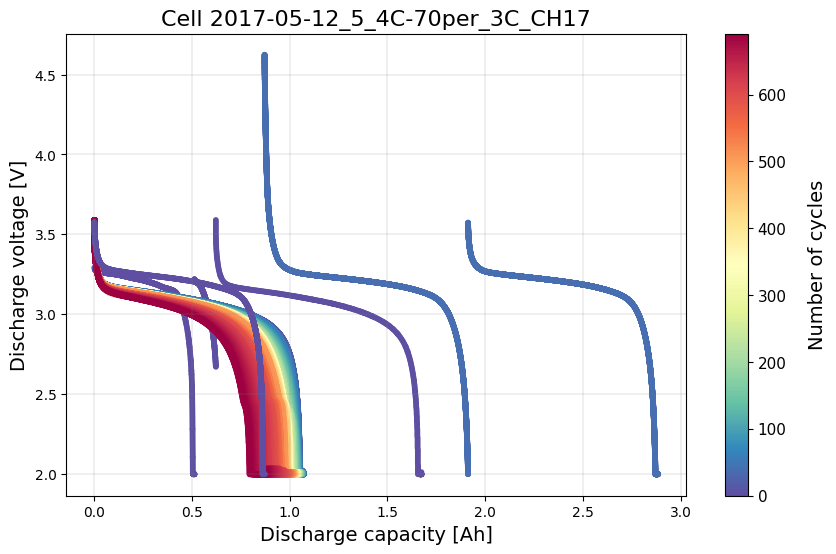

In [7]:
# If the true outlier cycle index is not known,
# cycling data will be plotted without labels
benchdb.plot_cycle_data(
    df_selected_cell_without_labels)

plt.show()

# Statistical Feature Transformation

To help with the separation of abnormal cycles from normal cycles, we propose a new statistical feature transformation method using the median and IQR of the input features:  

$$
\begin{equation}
x_\mathrm{scaled} = x_i - \left[\frac{\mathrm{median}(X)^{2}}{\mathrm{IQR}(X)}\right],
\end{equation} 
$$

where the IQR can be calculated from the third ($75^\mathrm{th}$ percentile) and first quartile ($25^\mathrm{th}$ percentile) of the input vector ($\mathrm{IQR}(X) = Q_3(X) - Q_1(X)$). Here, we use $\mathrm{median}(X)^2$ to preserve the physical unit of the original feature after feature transformation. Feature scaling is implemented on both the capacity and voltage data.

## Capacity scaling

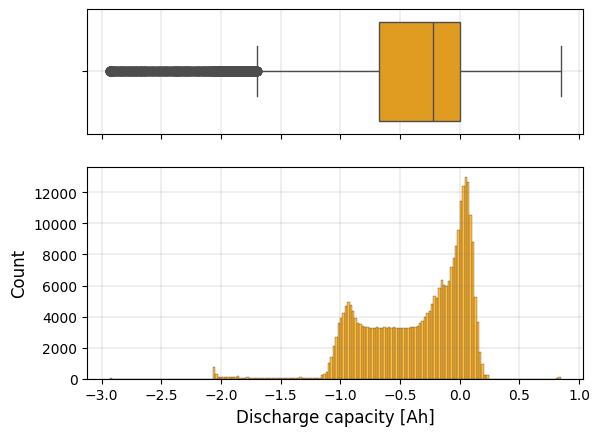

count    313326.000000
mean         -0.349626
std           0.414280
min          -2.933561
25%          -0.677412
50%          -0.226724
75%           0.005721
max           0.844670
Name: scaled_discharge_capacity, dtype: float64
**********************************************************************


0        -0.828787
1        -0.827432
2        -0.825870
3        -0.824306
4        -0.824306
            ...   
301553   -0.145985
301554   -0.145915
301555   -0.145915
301556   -0.145867
301557   -0.145867
Name: scaled_discharge_capacity, Length: 313326, dtype: float64

In [8]:
# Instantiate the CycleScaling class
scaler = CycleScaling(
    df_selected_cell=df_selected_cell_without_labels)

# Implement median IQR scaling on the discharge capacity data
df_capacity_med_scaled = scaler.median_IQR_scaling(
    variable="discharge_capacity",
    validate=True)

# Plot the histogram and boxplot of the scaled data
ax_hist = bviz.hist_boxplot(
    df_variable=df_capacity_med_scaled["scaled_discharge_capacity"])

ax_hist.set_xlabel(
    r"Discharge capacity [Ah]",
    fontsize=12)
ax_hist.set_ylabel(
    r"Count",
    fontsize=12)

plt.show()

# Print the summary statistics of the scaled capacity data
print(df_capacity_med_scaled["scaled_discharge_capacity"].describe())
print("*"*70)

df_capacity_med_scaled["scaled_discharge_capacity"]

## Voltage scaling

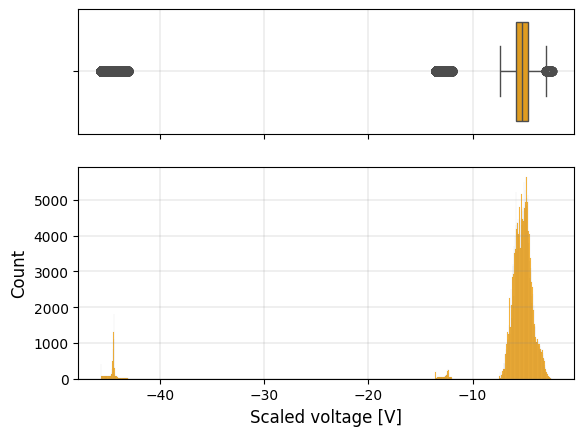

count    313326.000000
mean         -6.557421
std           7.159671
min         -45.644671
25%          -5.844655
50%          -5.215267
75%          -4.672330
max          -2.395836
Name: scaled_voltage, dtype: float64
**********************************************************************


0        -12.262836
1        -12.272870
2        -12.276842
3        -12.279593
4        -12.279593
            ...    
301553    -4.257652
301554    -4.257553
301555    -4.257553
301556    -4.257912
301557    -4.254364
Name: scaled_voltage, Length: 313326, dtype: float64

In [9]:
# Implement median IQR scaling on the discharge voltage data
df_voltage_med_scaled = scaler.median_IQR_scaling(
    variable="voltage",
    validate=True)

# Plot the histogram and boxplot of the scaled data
ax_hist = bviz.hist_boxplot(
    df_variable=df_voltage_med_scaled["scaled_voltage"])

ax_hist.set_xlabel(
    r"Scaled voltage [V]",
    fontsize=12)
ax_hist.set_ylabel(
    r"Count",
    fontsize=12)

plt.show()

# Print the summary statistics of the scaled capacity data
print(df_voltage_med_scaled["scaled_voltage"].describe())
print("*"*70)
df_voltage_med_scaled["scaled_voltage"]

# Physics-informed Feature Extraction

## Feature: dVdQ

In [10]:
df_max_dVdQ = scaler.calculate_max_feature_derivative_per_cycle(
    Xfeature=df_capacity_med_scaled["scaled_discharge_capacity"],
    Yfeature=df_voltage_med_scaled["scaled_voltage"],
    cycle_index=df_voltage_med_scaled["cycle_index"])

df_max_dVdQ

/home/mcp/Documents/02_learning/02_osbad/osbad/src/osbad/scaler.py:265: RuntimeWarning: divide by zero encountered in divide
  feature_diff = numerator_feature_diff/denominator_feature_diff
/home/mcp/Documents/02_learning/02_osbad/osbad/src/osbad/scaler.py:265: RuntimeWarning: invalid value encountered in divide
  feature_diff = numerator_feature_diff/denominator_feature_diff


,max_diff,log_max_diff,cycle_index
0,178932.163746,12.094762,0.0
1,10.879725,2.386901,1.0
2,9.355405,2.235954,2.0
3,7.779197,2.051453,3.0
4,9.119772,2.210445,4.0
...,...,...,...
687,8.897922,2.185818,687.0
688,7.007765,1.947019,688.0
689,7.087613,1.958349,689.0
690,7.316459,1.990126,690.0


In [11]:
max_dVdQ_feature_stats = bstats.calculate_feature_stats(
    df_max_dVdQ["max_diff"],
    new_col_name="max_diff_dVdQ")

max_dVdQ_feature_stats

Feature mean: 321.2474799595723
Feature max: 178932.16374587023
Feature min: 4.1214299224441175
Feature std: 6918.580867088768
**********************************************************************


,max_diff_dVdQ
max,178932.1637
min,4.1214
mean,321.2475
std,6918.5809


# Calculate the stats limits

## Standard deviation

In [12]:
sd_param_dict = bstats.outlier_method["sd"].params
print(sd_param_dict)

(SD_outlier_dVdQ_index,
 SD_min_limit_dVdQ,
 SD_max_limit_dVdQ) = bstats.outlier_method["sd"].compute(
    df_max_dVdQ["log_max_diff"], 
    **sd_param_dict)

{'std_dev_threshold': 3.0, 'ddof': 1}
SD feature mean: 2.559537423618379
SD feature std: 0.6559262319497828
SD lower bound: 0.5917587277690308
SD upper bound: 4.527316119467727
Std anomalous cycle index: [ 0 40]


## MAD

In [13]:
# Access the dict of parameters for using 
# the MAD method
mad_param_dict = bstats.outlier_method["mad"].params
print(mad_param_dict)

(MAD_outlier_index_dVdQ,
 MAD_min_limit_dVdQ,
 MAD_max_limit_dVdQ) = bstats.outlier_method["mad"].compute(
    df_max_dVdQ["log_max_diff"], 
    **mad_param_dict)

print("*"*70)
print(f"MAD outlier index on dVdQ: {MAD_outlier_index_dVdQ}")
print(df_max_dVdQ[df_max_dVdQ["cycle_index"].isin(MAD_outlier_index_dVdQ)])
print("*"*70)

{'mad_factor': None, 'mad_threshold': 3.0, 'ddof': 1}
Feature median: 2.4804507281050907
Feature z-score mean: 0.0
Feature z-score std. deviation: 1.0
MAD: 0.9391858202352378
MAD min limit: -0.33710673260062274
MAD max limit: 5.298008188810805
**********************************************************************
MAD outlier index on dVdQ: [ 0 40]
         max_diff  log_max_diff  cycle_index
0   178932.163746     12.094762          0.0
40   33622.153846     10.422940         40.0
**********************************************************************


## IQR

In [14]:
# Access the dict of parameters for using 
# the IQR method
iqr_param_dict = bstats.outlier_method["iqr"].params
print(iqr_param_dict)

(IQR_outlier_index_dVdQ,
 IQR_min_limit_dVdQ,
 IQR_max_limit_dVdQ) = bstats.outlier_method["iqr"].compute(
    df_max_dVdQ["log_max_diff"], 
    **iqr_param_dict)

print("*"*70)
print(f"IQR outlier index on dVdQ: {IQR_outlier_index_dVdQ}")
print(df_max_dVdQ[df_max_dVdQ["cycle_index"].isin(IQR_outlier_index_dVdQ)])
print("*"*70)

{'iqr_threshold': 1.5}
IQR lower limit: 1.507846654111778
IQR upper limit: 3.4634069217571612
**********************************************************************
IQR outlier index on dVdQ: [  0  33  34  40 105 141 249 280 320 338 339 476 497 548 555 557 566 567
 569 572 574 581 587 592 603 617 637 643 648 656 660 666 670 671 677 680
 691]
          max_diff  log_max_diff  cycle_index
0    178932.163746     12.094762          0.0
33       32.156096      3.470602         33.0
34       36.818579      3.606003         34.0
40    33622.153846     10.422940         40.0
105      34.429071      3.538901        105.0
141      33.819155      3.521027        141.0
249      32.607388      3.484539        249.0
280      39.508087      3.676505        280.0
320      39.395457      3.673651        320.0
338      35.666291      3.574206        338.0
339      33.351721      3.507109        339.0
476      32.454076      3.479826        476.0
497      32.786561      3.490019        497.0
548      35.

# Compare the stats limits

In [15]:
# Extract true outliers cycle index from benchmarking dataset
true_outlier_cycle_index = benchdb.get_true_outlier_cycle_index(
    df_selected_cell)
print(f"True outlier cycle index:")
print(true_outlier_cycle_index)

True outlier cycle index:
[  0.  40. 147. 148.]


## Normal cycles without outliers

In [16]:
df_max_dVdQ_normal = df_max_dVdQ[
    ~df_max_dVdQ["cycle_index"].isin(true_outlier_cycle_index)]

## Abnormal cycles with outlier scores

In [17]:
df_max_dVdQ_abnormal = df_max_dVdQ[
    df_max_dVdQ["cycle_index"].isin(true_outlier_cycle_index)]
abnormal_max_dVdQ = df_max_dVdQ_abnormal["log_max_diff"].values

df_max_dVdQ_abnormal["log_max_diff"]

0      12.094762
40     10.422940
147     2.782884
148     3.060974
Name: log_max_diff, dtype: float64

## Plot the stats limits

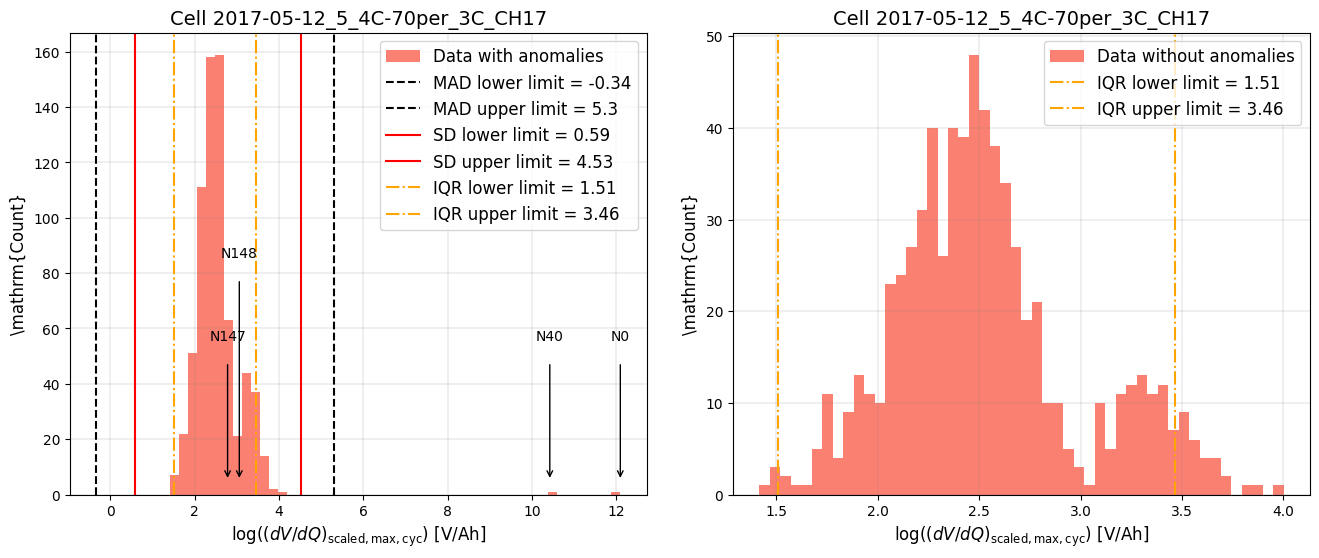

In [ ]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

fig = plt.figure(figsize=(16,6))
gs = fig.add_gridspec(1, 2, wspace=0.15)

ax1 = fig.add_subplot(gs[0])
ax1.hist(
    df_max_dVdQ["log_max_diff"],
    bins=50,
    color="salmon",
    label="Data with anomalies")
ax1.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)

# MAD-limits ---------------------------------------------------------
ax1.axvline(
    x=MAD_min_limit_dVdQ,
    color="black",
    linestyle="--",
    label=f"MAD lower limit = {np.round(MAD_min_limit_dVdQ, 2)}")

ax1.axvline(
    x=MAD_max_limit_dVdQ,
    color="black",
    linestyle="--",
    label=f"MAD upper limit = {np.round(MAD_max_limit_dVdQ, 2)}")

# Standard deviation limits -------------------------------------------
ax1.axvline(
    x=SD_min_limit_dVdQ,
    color="red",
    linestyle="-",
    label=f"SD lower limit = {np.round(SD_min_limit_dVdQ, 2)}")

ax1.axvline(
    x=SD_max_limit_dVdQ,
    color="red",
    linestyle="-",
    label=f"SD upper limit = {np.round(SD_max_limit_dVdQ, 2)}")

# IQR limits ------------------------------------------------------------
ax1.axvline(
    x=IQR_min_limit_dVdQ,
    color="orange",
    linestyle="-.",
    label=f"IQR lower limit = {np.round(IQR_min_limit_dVdQ, 2)}")

ax1.axvline(
    x=IQR_max_limit_dVdQ,
    color="orange",
    linestyle="-.",
    label=f"IQR upper limit = {np.round(IQR_max_limit_dVdQ, 2)}")

ax1.legend(loc="upper right", fontsize=12)
# ax1.set_xlim([-70, 500])
ax1.set_xlabel(
    r"$\log((dV/dQ)_\mathrm{scaled,max,cyc})$ [V/Ah]",
    fontsize=12)
ax1.set_ylabel(
    r"Count",
    fontsize=12)

ax1.set_title(
    f"Cell {selected_cell_label}",
    fontsize=14)

# Annotate where are the true labels in this limit comparison ------------

plt.annotate(
    f"N{df_max_dVdQ_abnormal["log_max_diff"].index[0]}\n" ,
    # The point (x,y) to annotate
    # The coordinate is determined by xycoords
     xy=(abnormal_max_dVdQ[0], 5),
    # The (x,y) position to place the text
     xytext=(abnormal_max_dVdQ[0], 50),
     horizontalalignment="center",
     arrowprops=dict(arrowstyle="->",lw=1))

plt.annotate(
    f"N{df_max_dVdQ_abnormal["log_max_diff"].index[1]}\n" ,
     xy=(abnormal_max_dVdQ[1], 5),
     xytext=(abnormal_max_dVdQ[1], 50),
     horizontalalignment="center",
     arrowprops=dict(arrowstyle="->",lw=1))

plt.annotate(
    f"N{df_max_dVdQ_abnormal["log_max_diff"].index[2]}\n" ,
     xy=(abnormal_max_dVdQ[2], 5),
     xytext=(abnormal_max_dVdQ[2], 50),
     horizontalalignment="center",
     arrowprops=dict(arrowstyle="->",lw=1))

plt.annotate(
    f"N{df_max_dVdQ_abnormal["log_max_diff"].index[3]}\n" ,
     xy=(abnormal_max_dVdQ[3], 5),
     xytext=(abnormal_max_dVdQ[3], 80),
     horizontalalignment="center",
     arrowprops=dict(arrowstyle="->",lw=1))

# -------------------------------------------------------------------------
# Normal histogram without anomalies
# To highlight why there are so many FP with the IQR method

ax2 = fig.add_subplot(gs[1])
ax2.hist(
    df_max_dVdQ_normal["log_max_diff"],
    bins=50,
    color="salmon",
    label="Data without anomalies")

# IQR limits ------------------------------------------------------------
ax2.axvline(
    x=IQR_min_limit_dVdQ,
    color="orange",
    linestyle="-.",
    label=f"IQR lower limit = {np.round(IQR_min_limit_dVdQ, 2)}")

ax2.axvline(
    x=IQR_max_limit_dVdQ,
    color="orange",
    linestyle="-.",
    label=f"IQR upper limit = {np.round(IQR_max_limit_dVdQ, 2)}")


ax2.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax2.legend(loc="upper right", fontsize=12)
ax2.set_xlabel(
    r"$\log((dV/dQ)_\mathrm{scaled,max,cyc})$ [V/Ah]",
    fontsize=12)
ax2.set_ylabel(
    r"Count",
    fontsize=12)
ax2.set_title(
    f"Cell {selected_cell_label}",
    fontsize=14)

output_fig_filename = (
    "compare_hist_limit_dVdQ_" 
    + selected_cell_label 
    + ".png")

fig_output_path = (
    selected_cell_artifacts_dir
    .joinpath(output_fig_filename))

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()